## README:

This notebook performs essential validations on the final dataset. 

Visual and correlation anaylses are also performed to select the final set of features for model training.

**NOTE**: Cells labeled with '## ----- CONFIG ----- ##' contain parameters that need to be set manually 

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dotenv import load_dotenv

In [2]:
# add project root to path
root_path = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(root_path)

## Load env variables

In [3]:
load_dotenv(r'../.env')

DATA_DIR = os.getenv('DATA_DIR')

## Load data

In [4]:
data_df = pd.read_csv(os.path.join(DATA_DIR, 'data_with_features.csv'))
data_df.shape

(67300, 35)

In [5]:
data_df.columns

Index(['date', 'tic', 'close', 'high', 'low', 'open', 'volume', 'BAMLH0A0HYM2',
       'BOGMBASE', 'CPIAUCSL', 'DFF', 'ICSA', 'PPIACO', 'REAINTRATREARAT10Y',
       'T10Y2Y', 'USEPUINDXD', 'USREC', 'USSLIND', 'USSTHPI', 'VIXCLS',
       'day_of_year', 'month_of_year', 'day_of_week', 'doy_sin', 'doy_cos',
       'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'atr_30', 'macd',
       'macd_signal', 'macd_hist', 'cci_30', 'rsi_30'],
      dtype='object')

In [6]:
# get data attributes
nrows = data_df.shape[0]
n_per_tic = data_df['date'].nunique()
ntics = data_df['tic'].nunique()
tic_list = data_df['tic'].unique()

print('nrows', nrows)
print('rows per ticker:', n_per_tic)
print('n tickers', ntics)
print('tickers', tic_list)

nrows 67300
rows per ticker: 6730
n tickers 10
tickers ['AAPL' 'AMZN' 'F' 'JPM' 'MSFT' 'NVDA' 'PG' 'SPY' 'UNH' 'XOM']


## Validations

In [7]:
# check for NAs
assert ~data_df.isna().any().any()

In [8]:
# check if dates follow format %Y-%m-%d
# an error would be raised if a date string cannot be converted
dt_index = pd.to_datetime(data_df['date'], format='%Y-%m-%d')
data_df = data_df.set_index(dt_index)

In [9]:
# check if rows are equally distributed between stock tickers
assert all(nrows / ntics == data_df['tic'].value_counts())
assert n_per_tic == nrows / ntics

In [10]:
# check if every ticker has the same dates
dates = data_df.query(f"tic == '{tic_list[0]}'")['date'].values
for tic in tic_list[1:]:
    dates2 = data_df.query(f"tic == '{tic}'")['date'].values
    assert all(dates == dates2)

In [11]:
# check if low <= open <= high, low <= close <= high
threshold = 1e7
a = abs(data_df['low'] - data_df['open']) < threshold
b = abs(data_df['open'] <= data_df['high']) < threshold
c = abs(data_df['low'] <= data_df['close']) < threshold
d = abs(data_df['close'] <= data_df['high']) < threshold
assert all(a)
assert all(b)
assert all(c)
assert all(d)

## Analysis config

In [12]:
## ----- CONFIG ----- ##
date_split = '2018-01-01' # choose a date to split between training and testing

In [ ]:
# applies train-test split
split_query = data_df.index < date_split
train_n = data_df.index[split_query].nunique()
test_n = data_df.index[~split_query].nunique()
print(f'training: {train_n} ({round(100 * train_n / n_per_tic, 2)}%)',
      f'testing: {test_n} ({round(100 * test_n / n_per_tic, 2)}%)',
      sep='\n')

training: 4734 (70.34%)
testing: 1996 (29.66%)


## Analysis - prices

Visually inspect trends and seasonality

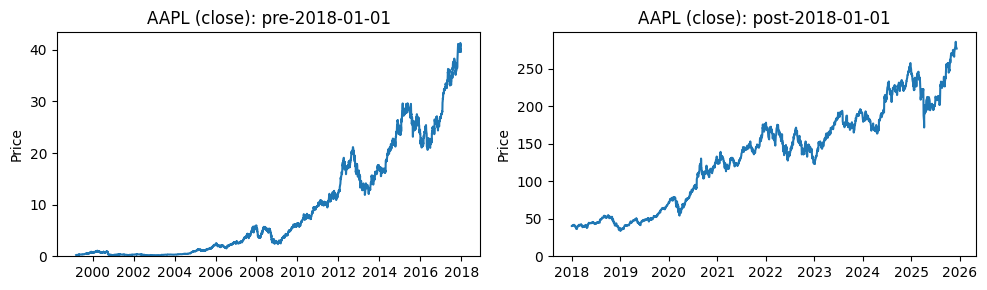

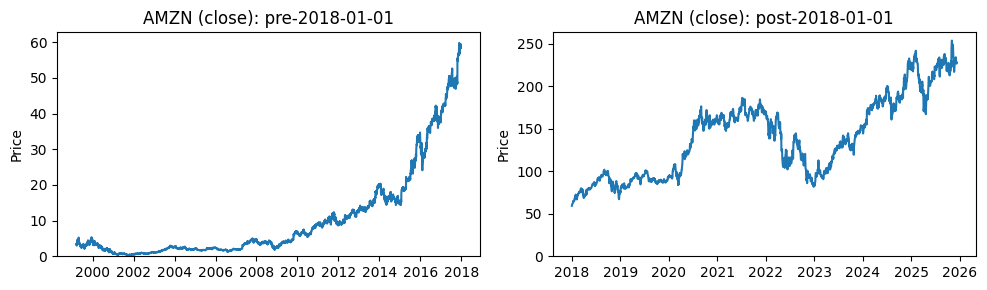

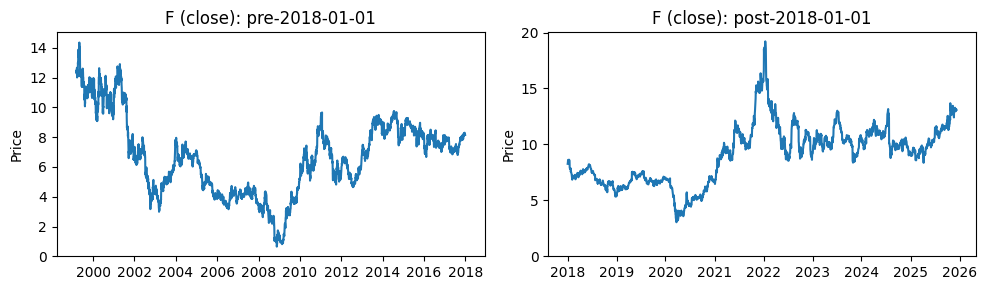

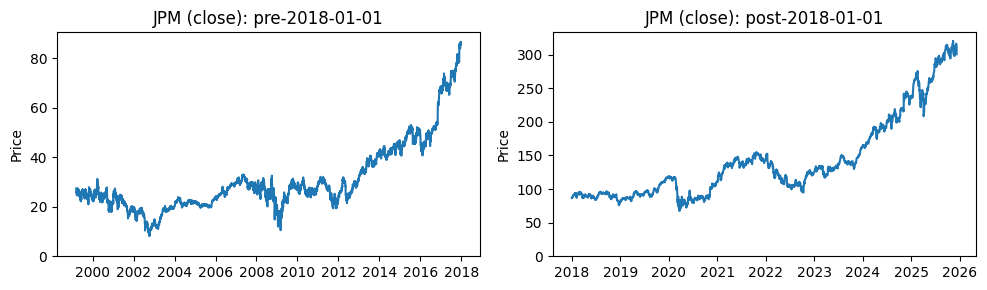

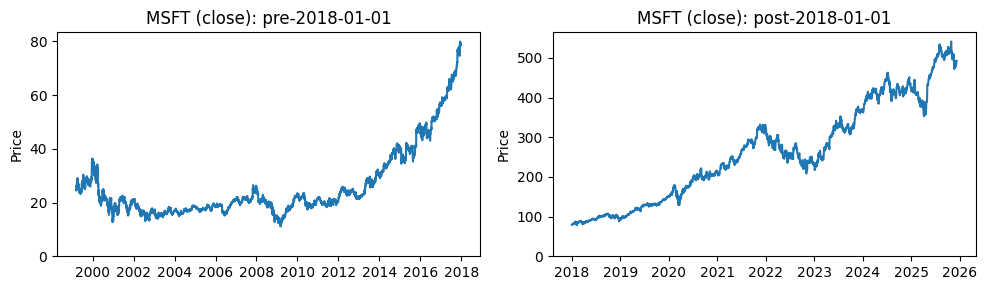

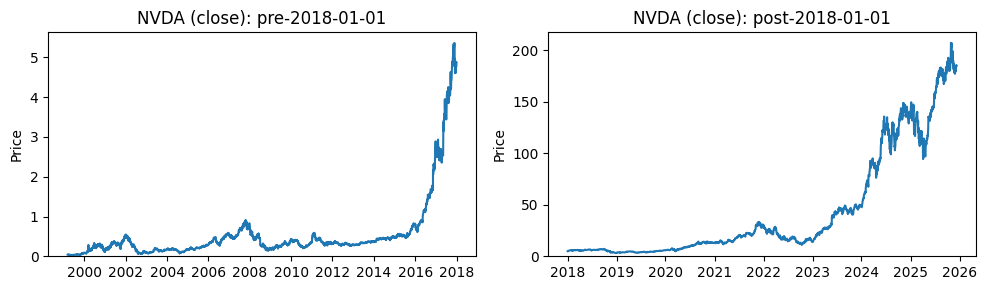

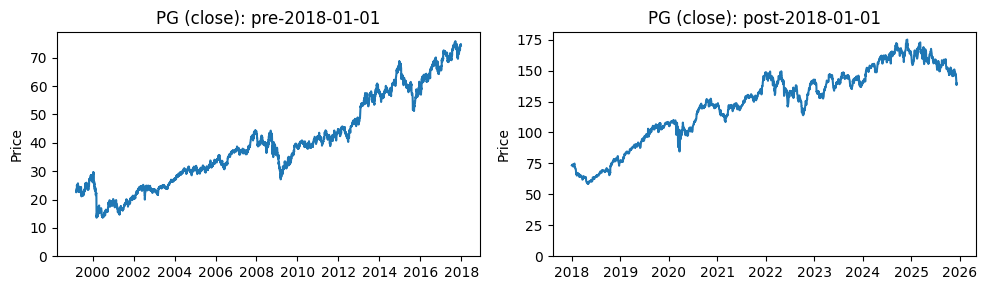

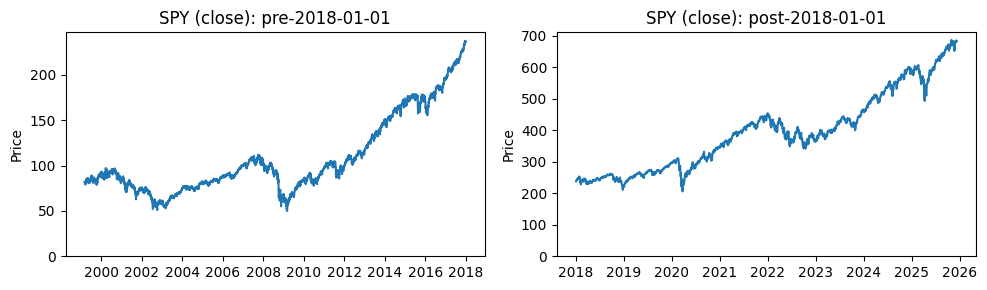

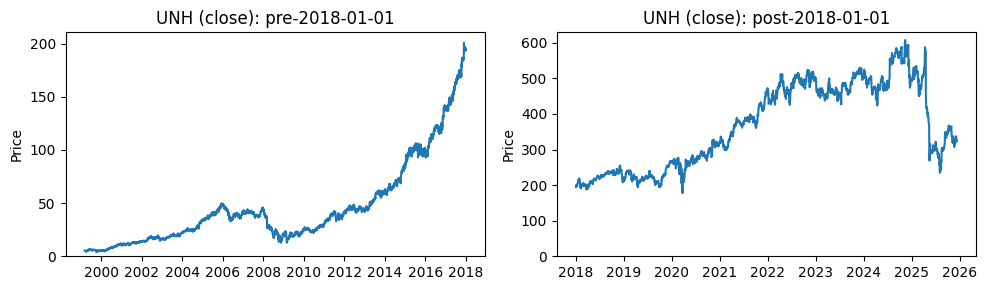

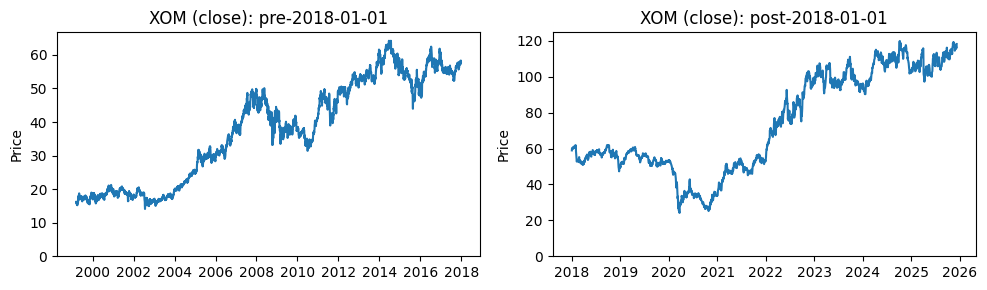

In [14]:
price = 'close'

for tic in tic_list:
    sub_df = data_df.query(f"tic == '{tic}'")

    fig, (ax1, ax2) = plt.subplots(figsize=(10,3), nrows=1, ncols=2)
    ax1.set_title(f'{tic} ({price}): pre-{date_split}')
    ax1.set_ylabel('Price')
    ax1.plot(sub_df.query(f"date < '{date_split}'")[price])
    ax1.set_ylim(0)

    ax2.set_title(f'{tic} ({price}): post-{date_split}')
    ax2.set_ylabel('Price')
    ax2.plot(sub_df.query(f"date >= '{date_split}'")[price])
    ax2.set_ylim(0)

    plt.tight_layout()

## Analysis - features

In [15]:
## ----- CONFIG ----- ##
# NOTE: lists of features need to be manually updated if modifications are made on upstream steps

# list of features specific to each stock
STOCK_FEATURES = [
    'atr_30',
    'macd', 
    'macd_signal', 
    'macd_hist', 
    'rsi_30',
    'cci_30'
]

# list of features shared by stocks
ECONOMY_FEATURES = [
    'BAMLH0A0HYM2',
    'BOGMBASE', 
    'CPIAUCSL', 
    'DFF', 
    'ICSA', 
    'PPIACO', 
    'REAINTRATREARAT10Y',
    'T10Y2Y', 
    'USEPUINDXD', 
    'USREC', 
    'USSLIND', 
    'USSTHPI', 
    'VIXCLS',
    'doy_sin', 'doy_cos',
    'month_sin', 'month_cos',
    'dow_sin', 'dow_cos'
]

FEATURE_COLS = STOCK_FEATURES + ECONOMY_FEATURES
print('Stock features:', len(STOCK_FEATURES))
print('Economy features:', len(ECONOMY_FEATURES))
print('All features:', len(FEATURE_COLS))

Stock features: 6
Economy features: 19
All features: 25


### Visualize economy features

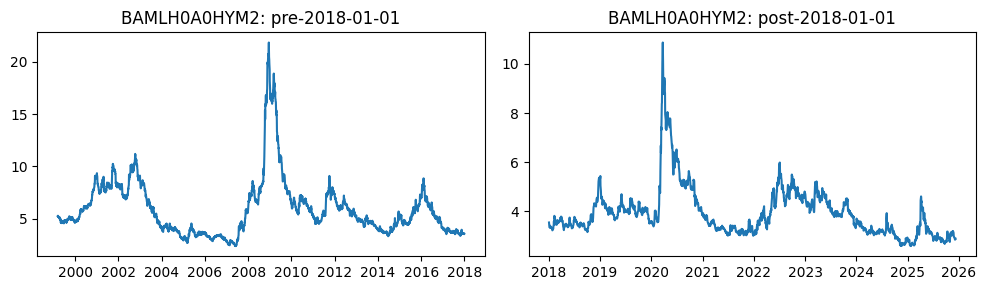

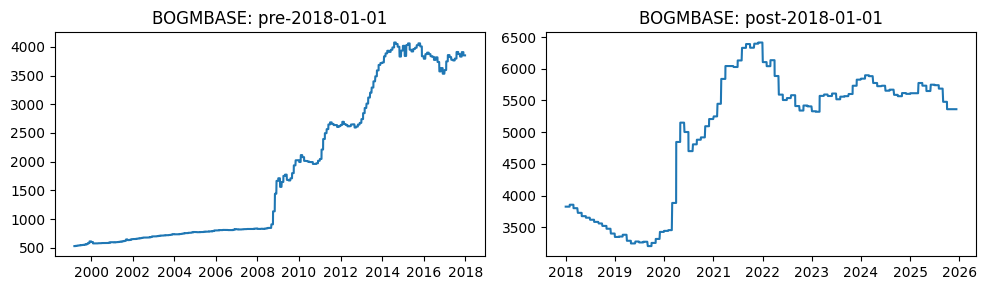

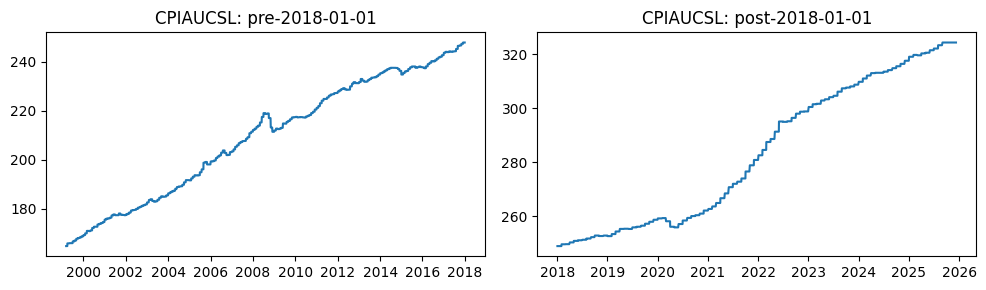

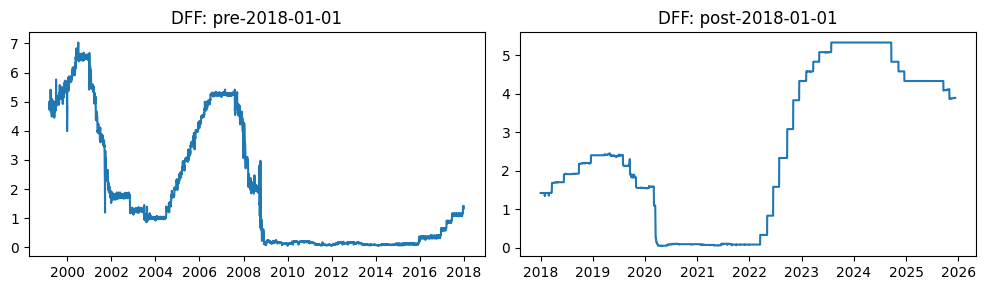

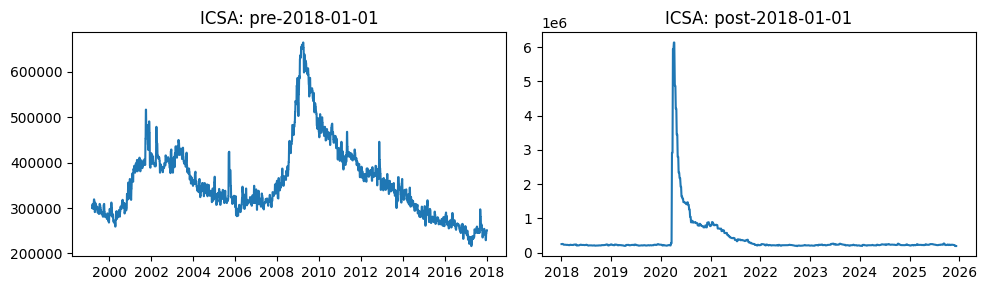

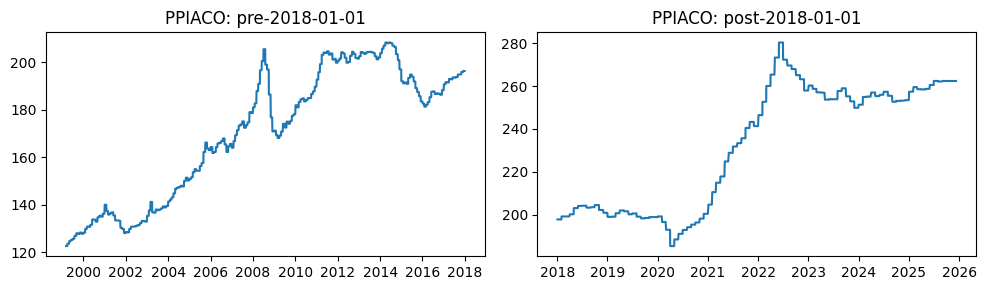

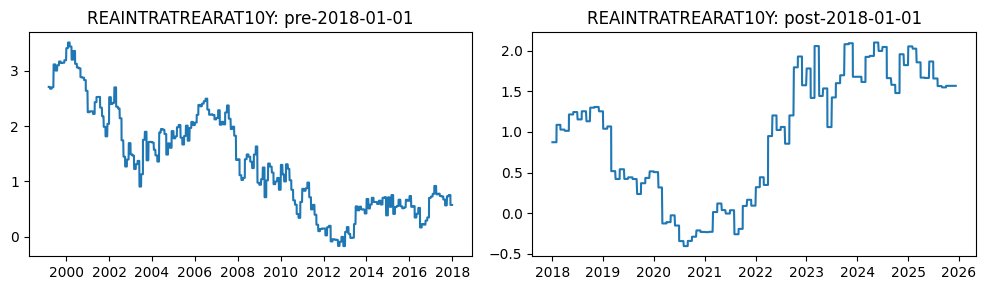

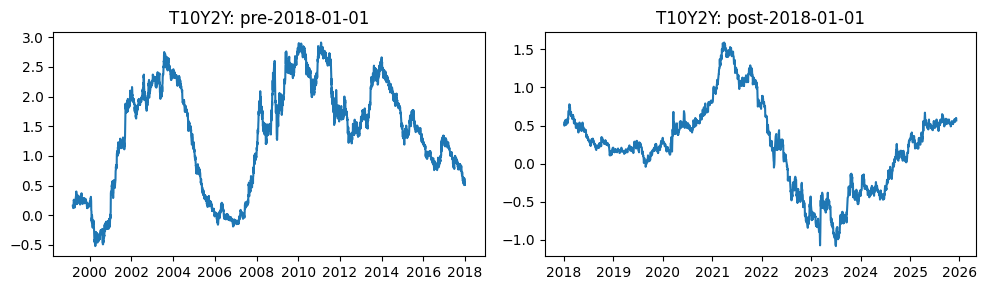

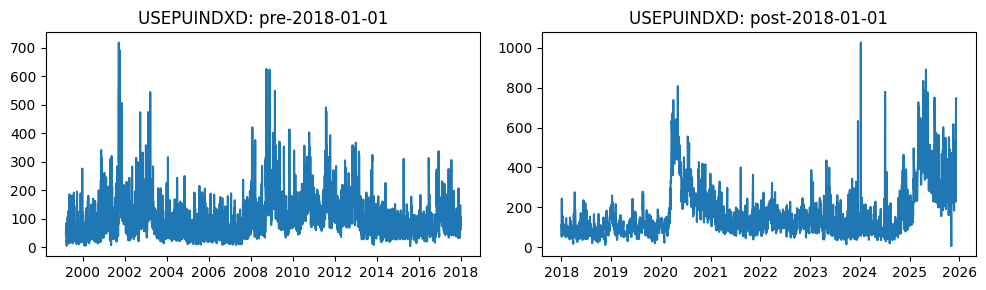

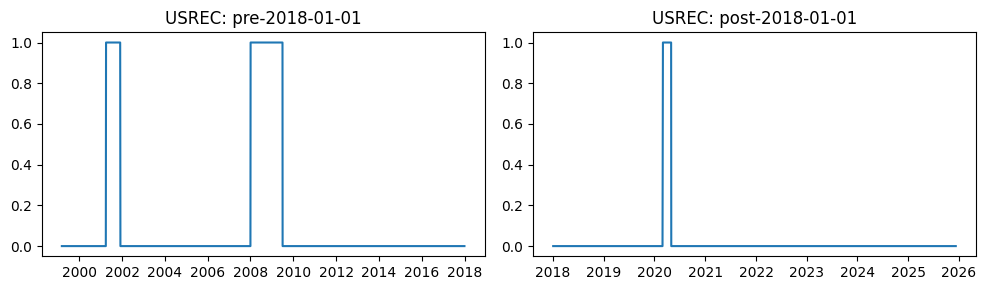

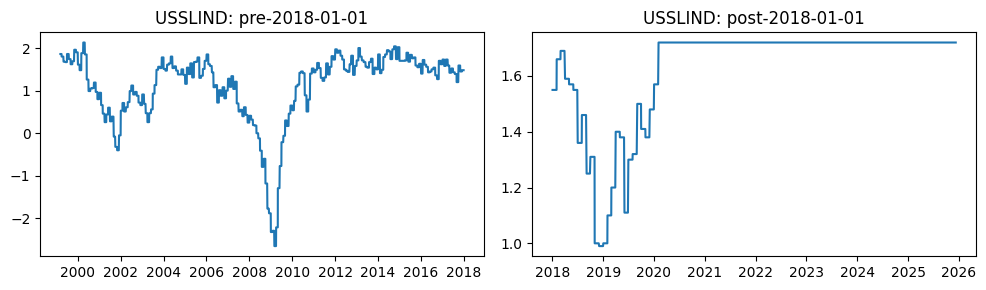

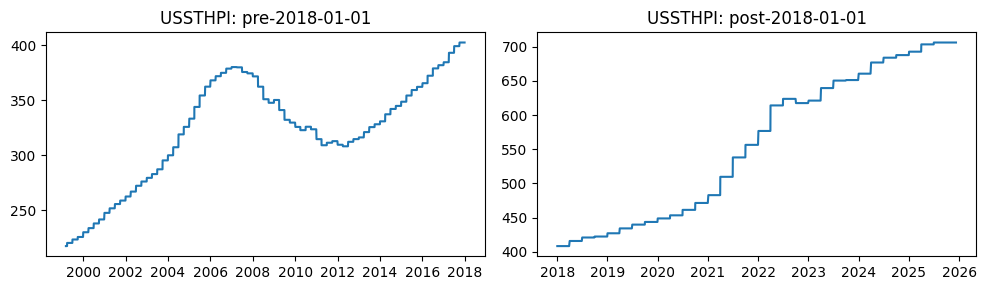

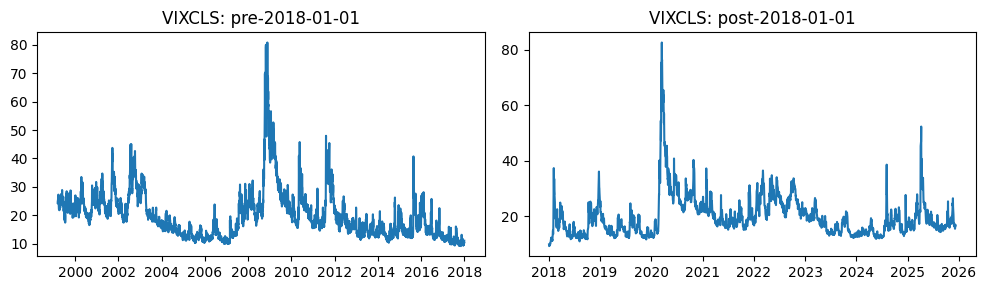

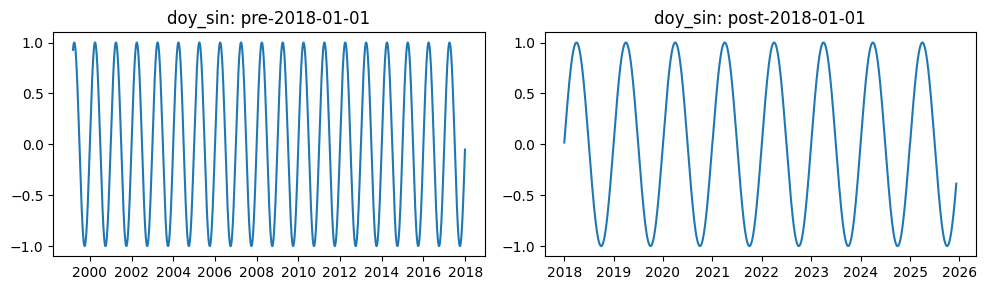

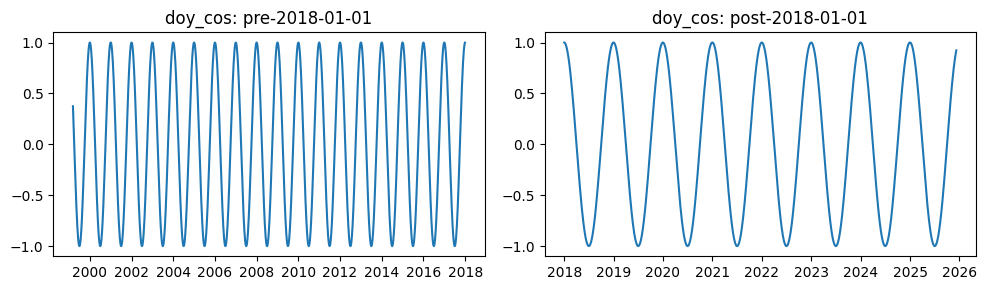

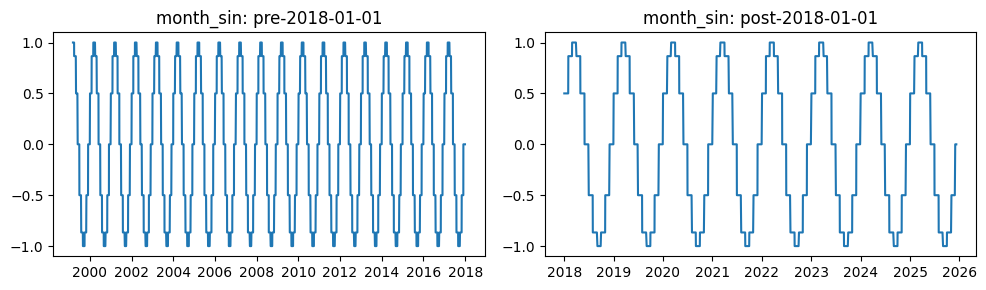

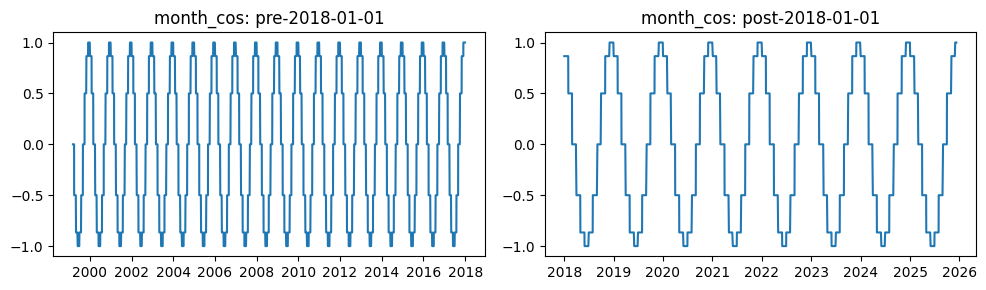

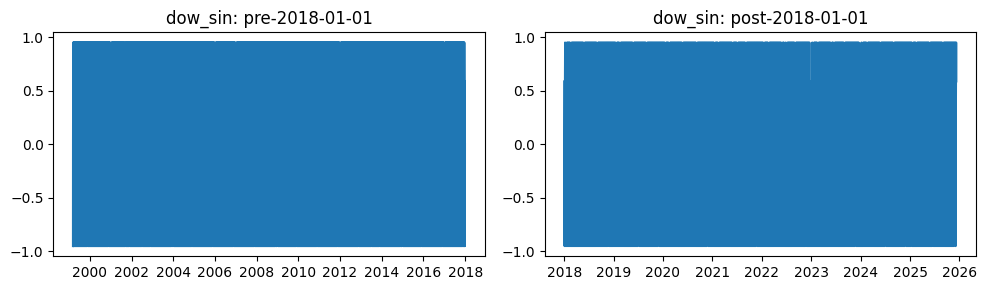

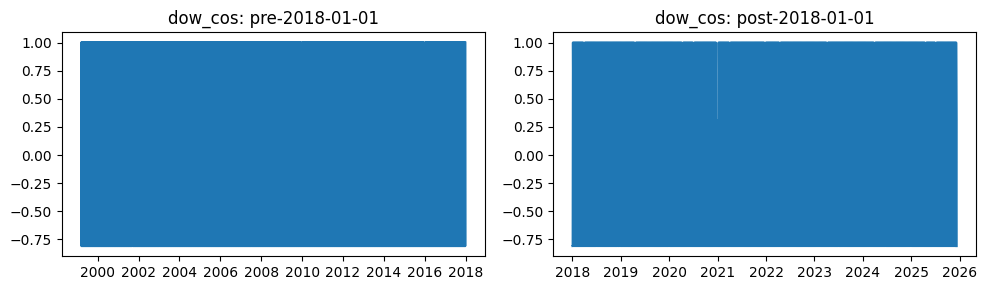

In [16]:
# use data for one tic (since economic features are shared)
sub_df = data_df.query(f"tic == '{tic_list[0]}'")[ECONOMY_FEATURES]

for feat in ECONOMY_FEATURES:
    fig, (ax1, ax2) = plt.subplots(figsize=(10,3), nrows=1, ncols=2)
    ax1.set_title(f'{feat}: pre-{date_split}')
    ax1.plot(sub_df.query(f"date < '{date_split}'")[feat])

    ax2.set_title(f'{feat}: post-{date_split}')
    ax2.plot(sub_df.query(f"date >= '{date_split}'")[feat])

    plt.tight_layout()

### Feature correlation

In [17]:
# correlation amongst features
corr_df = data_df[FEATURE_COLS].corr()

# get pair-wise structure
pairwise_corr = (
    corr_df.stack()
        .reset_index()
        .rename(columns={'level_0': 'var1',
                         'level_1': 'var2',
                         0: 'corr'})
)

# get unique pairs
pairwise_corr = pairwise_corr[pairwise_corr['var1'] < pairwise_corr['var2']]

# get absolute value of correlation
pairwise_corr['abs_corr'] = abs(pairwise_corr['corr'])

# see distribution
pairwise_corr[['abs_corr']].describe(percentiles=[0.8, 0.9, 0.95]).T

,count,mean,std,min,50%,80%,90%,95%,max
abs_corr,300.0,0.143765,0.216672,0.000054,0.049655,0.252227,0.397639,0.670783,0.962547


In [18]:
# get highly correlated pairs
pairwise_corr[pairwise_corr['abs_corr'] >= 0.75].sort_values('corr', ascending=False)

,var1,var2,corr,abs_corr
211,CPIAUCSL,PPIACO,0.962547,0.962547
496,doy_sin,month_sin,0.951247,0.951247
522,doy_cos,month_cos,0.949021,0.949021
27,macd,macd_signal,0.948964,0.948964
217,CPIAUCSL,USSTHPI,0.938132,0.938132
183,BOGMBASE,CPIAUCSL,0.937232,0.937232
186,BOGMBASE,PPIACO,0.895326,0.895326
292,PPIACO,USSTHPI,0.882402,0.882402
192,BOGMBASE,USSTHPI,0.824879,0.824879
237,DFF,REAINTRATREARAT10Y,0.816543,0.816543


In [ ]:
## ----- CONFIG ----- ##
exclude_cols = [
    # 1) excluded due to high correlation with other features (redundancy)
    'PPIACO',
    'month_sin', 'month_cos',
    'macd_signal',
    'USSTHPI', 
    'BOGMBASE',
    'REAINTRATREARAT10Y',
    'cci_30', # exclude one of two trends indicator
    'BAMLH0A0HYM2',
    # -------------------

    # 2) excluded due to low variation in data
    'USSLIND',
    'USREC'
    # -------------------
]

In [20]:
SELECTED_FEATURE_COLS = FEATURE_COLS.copy()

for col in exclude_cols:
    SELECTED_FEATURE_COLS.remove(col)

print('Number of selected features:', len(SELECTED_FEATURE_COLS))
SELECTED_FEATURE_COLS  

Number of selected features: 14


['atr_30',
 'macd',
 'macd_hist',
 'rsi_30',
 'CPIAUCSL',
 'DFF',
 'ICSA',
 'T10Y2Y',
 'USEPUINDXD',
 'VIXCLS',
 'doy_sin',
 'doy_cos',
 'dow_sin',
 'dow_cos']

## Analysis - Regime-change

In [21]:
import warnings
from statsmodels.tsa.api import VAR
from scipy.stats import chi2

In [22]:
# IN-CODE CITATION:
# Generated by ChatGPT 5.2 (OpenAI) on Dec 13, 2025.
# Prompt used:
# """Give me a Python function to detect regime change between two
# multivariate data series split on a single date. The function should
# fit a VAR on two dataframes and infer significance of regime change given an alpha
# value. The columns of the dataframes are variable names.
# """
# Code has been manually tested and verified for accuracy and slightly modified.
def var_regime_change_test(
    df_left: pd.DataFrame,
    df_right: pd.DataFrame,
    alpha: float = 0.05,
    p: int | None = None,
    maxlags: int = 10,
) -> bool:
    """
    Test for a regime change between two multivariate time series
    using a pooled-vs-split VAR likelihood ratio test.

    Parameters
    ----------
    df_left, df_right : pandas.DataFrame
        Time-ordered data. Columns must match.
    alpha : float
        Significance level (e.g., 0.05).
    p : int or None
        VAR lag order. If None, selected by AIC on pooled data.
    maxlags : int
        Max lag to consider if p is None.

    Returns
    -------
    bool
        True  -> reject null (regime change detected)
        False -> fail to reject null
    """
    k = df_left.shape[1]

    # --- pooled data ---
    df_pool = pd.concat([df_left, df_right], axis=0)

    # --- select lag order if needed ---
    if p is None:
        order_res = VAR(df_pool).select_order(maxlags=maxlags)
        p = order_res.aic

        if p is None or p == 0:
            raise ValueError("Lag order selection failed or returned p=0.")

    # --- fit VARs ---
    res_left  = VAR(df_left).fit(p)
    res_right = VAR(df_right).fit(p)
    res_pool  = VAR(df_pool).fit(p)

    # --- likelihood ratio statistic ---
    LR = 2.0 * (res_left.llf + res_right.llf - res_pool.llf)

    # --- degrees of freedom ---
    # Number of parameters per VAR:
    # k intercepts + k^2 * p lag coefficients
    n_params = k + k * k * p
    df = n_params  # difference between split and pooled

    # --- p-value ---
    p_value = 1.0 - chi2.cdf(LR, df=df)

    return p_value < alpha

In [23]:
# select variables to include for regime-change detection
regime_cols = [
    'close',
    'CPIAUCSL',
    'DFF',
    'ICSA',
    'T10Y2Y',
    'USEPUINDXD',
    'VIXCLS'
]

In [24]:
# apply regime-change test to each stock at the 5% significance level
for tic in tic_list:
    sub_df = data_df.query(f"tic == '{tic}'")
    left_df = sub_df.query(f"date < '{date_split}'")[regime_cols]
    right_df = sub_df.query(f"date >= '{date_split}'")[regime_cols]
    warnings.filterwarnings("ignore")
    change_detected = var_regime_change_test(left_df, right_df, alpha=0.05, p=1)
    print(tic, change_detected)

AAPL True
AMZN True
F True
JPM True
MSFT True
NVDA True
PG True
SPY True
UNH True
XOM True
